# 예제 1: 전선 공장 불량 데이터 탐색 분석 (EDA)

---

## 이 예제에서 배울 것
- 데이터를 **표 형태(DataFrame)**로 만드는 방법
- 숫자로만 보이던 데이터를 **그래프**로 시각화하는 방법
- 눈으로는 보이지 않던 **불량 패턴**을 AI 없이도 데이터로 발견하는 방법

## 핵심 메시지
> **"데이터를 보면 답이 보인다."**  
> AI를 쓰기 전에, 먼저 데이터를 시각화하는 것만으로도 큰 인사이트를 얻을 수 있습니다.

## 제조 현장 연관
- 라인별 불량률 비교 → **어느 라인이 문제인지** 즉시 파악
- 월별 트렌드 → **계절성 또는 공정 변화** 파악
- 온도·압력과 불량의 관계 → **원인 변수 추정**

## STEP 1: 필요한 도구(라이브러리) 준비

파이썬에서는 다양한 '도구 상자(라이브러리)'를 불러와서 사용합니다.  
마치 엑셀, 파워포인트를 열기 전에 프로그램을 설치하는 것과 같습니다.

| 라이브러리 | 역할 | 비유 |
|-----------|------|------|
| `pandas` | 표(DataFrame) 형태로 데이터 다루기 | 엑셀 같은 것 |
| `numpy` | 수학 계산 (평균, 랜덤 등) | 계산기 |
| `matplotlib` | 그래프 그리기 | 파워포인트 차트 기능 |
| `koreanize_matplotlib` | 그래프에서 한글 깨짐 방지 | 한글 폰트 설치 |

In [1]:
# ─────────────────────────────────────────────────────────
# 한글 그래프를 위한 도구 설치
# !pip install 명령어: 인터넷에서 도구를 다운로드하여 설치합니다
# -q 옵션: 설치 과정 메시지를 간략하게 표시 (quiet 모드)
# ─────────────────────────────────────────────────────────
!pip install -q koreanize-matplotlib

In [2]:
# ─────────────────────────────────────────────────────────
# 라이브러리 불러오기
# import: "이 도구를 사용하겠다"는 선언
# as pd, as np 등: 긴 이름을 짧게 줄여서 쓰기 위한 별명
# ─────────────────────────────────────────────────────────
import pandas as pd           # 표 형태 데이터 처리 (pd라는 별명으로 사용)
import numpy as np            # 수학 계산 (np라는 별명으로 사용)
import matplotlib.pyplot as plt  # 그래프 그리기 (plt라는 별명으로 사용)
import koreanize_matplotlib   # 한글 폰트 자동 설정 (별명 없이 그냥 import)

# 설치 및 불러오기가 완료되면 아래 메시지가 출력됩니다
print("✅ 모든 도구 준비 완료!")

✅ 모든 도구 준비 완료!


## STEP 2: 실습용 데이터 만들기

실제 공장 데이터를 가져오는 대신, **비슷한 패턴의 가상 데이터**를 만들어서 연습합니다.  
실제 교육 현장에서는 이 부분을 실제 MES/ERP 데이터로 교체하면 됩니다.

**데이터 구조:**
```
날짜 | 라인 | 제품코드 | 생산량 | 온도 | 압력 | 불량수 | 불량률
```

In [4]:
# ─────────────────────────────────────────────────────────
# 재현 가능한 랜덤 데이터 생성
# np.random.seed(42): "42번 방식으로 랜덤을 시작"이라는 의미
#   → 이 숫자를 고정하면 실행할 때마다 똑같은 '랜덤' 데이터가 나옵니다
#   → 선생님과 학생이 같은 결과를 볼 수 있어서 교육에 편리합니다
# ─────────────────────────────────────────────────────────
np.random.seed(42)

n = 300  # 데이터 개수: 300일치 데이터를 만들겠다는 의미

# ─────────────────────────────────────────────────────────
# 각 라인의 불량 발생 확률 설정
# 딕셔너리({}): 키=값 형태로 여러 정보를 묶어두는 자료 구조
# 라인C를 의도적으로 2.5%로 높게 설정 → AI가 나중에 이걸 찾아냄!
# ─────────────────────────────────────────────────────────
불량률_기준 = {
    '라인A': 0.010,   # 1.0% 불량률
    '라인B': 0.008,   # 0.8% 불량률 (가장 양호)
    '라인C': 0.025,   # 2.5% 불량률 (문제 라인! 나중에 발견됨)
}

# ─────────────────────────────────────────────────────────
# DataFrame 생성: 엑셀 표와 비슷한 형태의 데이터 구조
# pd.DataFrame({}): 중괄호 안의 내용을 표로 만들어 줌
# '컬럼명': 데이터값  형태로 각 열을 정의합니다
# ─────────────────────────────────────────────────────────
data = pd.DataFrame({
    # pd.date_range: 날짜 범위를 자동으로 생성
    '날짜': pd.date_range('2024-01-01', periods=n),
    
    # np.random.choice: 목록 중 랜덤하게 하나씩 선택
    '라인': np.random.choice(['라인A', '라인B', '라인C'], n),
    '제품코드': np.random.choice(['W001(전선)', 'W002(케이블)', 'W003(코드)'], n),
    
    # np.random.randint(최소, 최대, 개수): 정수 난수 생성
    '생산량': np.random.randint(100, 500, n),
    
    # np.random.normal(평균, 표준편차, 개수): 정규분포 난수 생성
    # 실제 공장 온도, 압력 등은 이렇게 정규분포를 따르는 경우가 많습니다
    '온도(°C)': np.random.normal(85, 5, n),      # 평균 85도, 변동 ±5도
    '압력(MPa)': np.random.normal(2.5, 0.3, n),  # 평균 2.5, 변동 ±0.3
})

# ─────────────────────────────────────────────────────────
# 불량수 계산: 각 행(라인)마다 해당 라인의 불량률을 적용
# lambda: 간단한 함수를 한 줄로 만드는 방법
#   r: 각 행을 의미 (row의 약자)
#   r['라인']: 해당 행의 '라인' 값 (예: '라인A')
# np.random.poisson: 포아송 분포 (드물게 발생하는 사건 수에 사용)
# ─────────────────────────────────────────────────────────
data['불량수'] = data.apply(
    lambda r: np.random.poisson(r['생산량'] * 불량률_기준[r['라인']]),
    axis=1  # axis=1: 행(가로) 방향으로 적용
)

# 불량률 계산: 불량수 ÷ 생산량 × 100 (퍼센트)
data['불량률(%)'] = data['불량수'] / data['생산량'] * 100

print("✅ 데이터 생성 완료!")
print(f"총 {len(data)}일 데이터 생성됨")
print(f"컬럼(열) 목록: {list(data.columns)}")
print("\n 처음 5행 미리보기:")
data.head()  # head(): 처음 5행만 보여주는 함수

✅ 데이터 생성 완료!
총 300일 데이터 생성됨
컬럼(열) 목록: ['날짜', '라인', '제품코드', '생산량', '온도(°C)', '압력(MPa)', '불량수', '불량률(%)']

 처음 5행 미리보기:


,날짜,라인,제품코드,생산량,온도(°C),압력(MPa),불량수,불량률(%)
0,2024-01-01,라인C,W003(코드),152,78.907552,2.355963,3,1.973684
1,2024-01-02,라인A,W001(전선),250,79.198375,3.189541,3,1.200000
2,2024-01-03,라인C,W001(전선),243,84.791870,2.119594,6,2.469136
3,2024-01-04,라인C,W001(전선),156,80.499422,2.101256,6,3.846154
4,2024-01-05,라인A,W001(전선),138,85.612527,2.996494,3,2.173913


## STEP 3: 기초 통계 확인

그래프를 그리기 전에, 숫자로 먼저 파악해봅니다.  
이것이 **데이터 탐색(EDA: Exploratory Data Analysis)**의 첫 단계입니다.

In [5]:
# ─────────────────────────────────────────────────────────
# 라인별 불량률 통계 계산
# groupby('라인'): 라인 종류별로 데이터를 묶기 (엑셀 피벗테이블과 유사)
# ['불량률(%)']: 불량률 열만 선택
# .agg([...]): 여러 통계를 한번에 계산
#   'mean' = 평균, 'max' = 최대값, 'std' = 표준편차(변동성)
# ─────────────────────────────────────────────────────────
라인별_불량률 = data.groupby('라인')['불량률(%)'].agg(['mean', 'max', 'std'])

# 컬럼 이름을 이해하기 쉽게 변경
라인별_불량률.columns = ['평균 불량률(%)', '최대 불량률(%)', '불량률 변동성']

# round(소수점자리): 소수점 아래 지정 자리까지 반올림
print("=" * 50)
print("📊 라인별 불량률 통계")
print("=" * 50)
print(라인별_불량률.round(3))

# ─────────────────────────────────────────────────────────
# 💡 발견: 라인C가 다른 라인의 2~3배 불량률
# 이것을 그래프로 보면 더 명확하게 보입니다 (다음 STEP에서!)
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("📊 월별 불량률 추이")
print("=" * 50)

# dt.month: 날짜 데이터에서 월(月)만 추출
data['월'] = data['날짜'].dt.month
월별_불량률 = data.groupby('월')['불량률(%)'].mean().round(3)
print(월별_불량률)

📊 라인별 불량률 통계
     평균 불량률(%)  최대 불량률(%)  불량률 변동성
라인                                
라인A      1.045      3.774    0.644
라인B      0.771      2.646    0.576
라인C      2.517      6.422    1.033

📊 월별 불량률 추이
월
1     1.673
2     1.539
3     0.933
4     1.586
5     1.665
6     1.385
7     1.348
8     1.388
9     1.648
10    1.725
Name: 불량률(%), dtype: float64


## STEP 4: 시각화 — 데이터를 그래프로 보기

숫자로 보던 데이터를 그래프로 만들어봅시다.  
**4가지 그래프**를 한 화면에 동시에 그립니다.

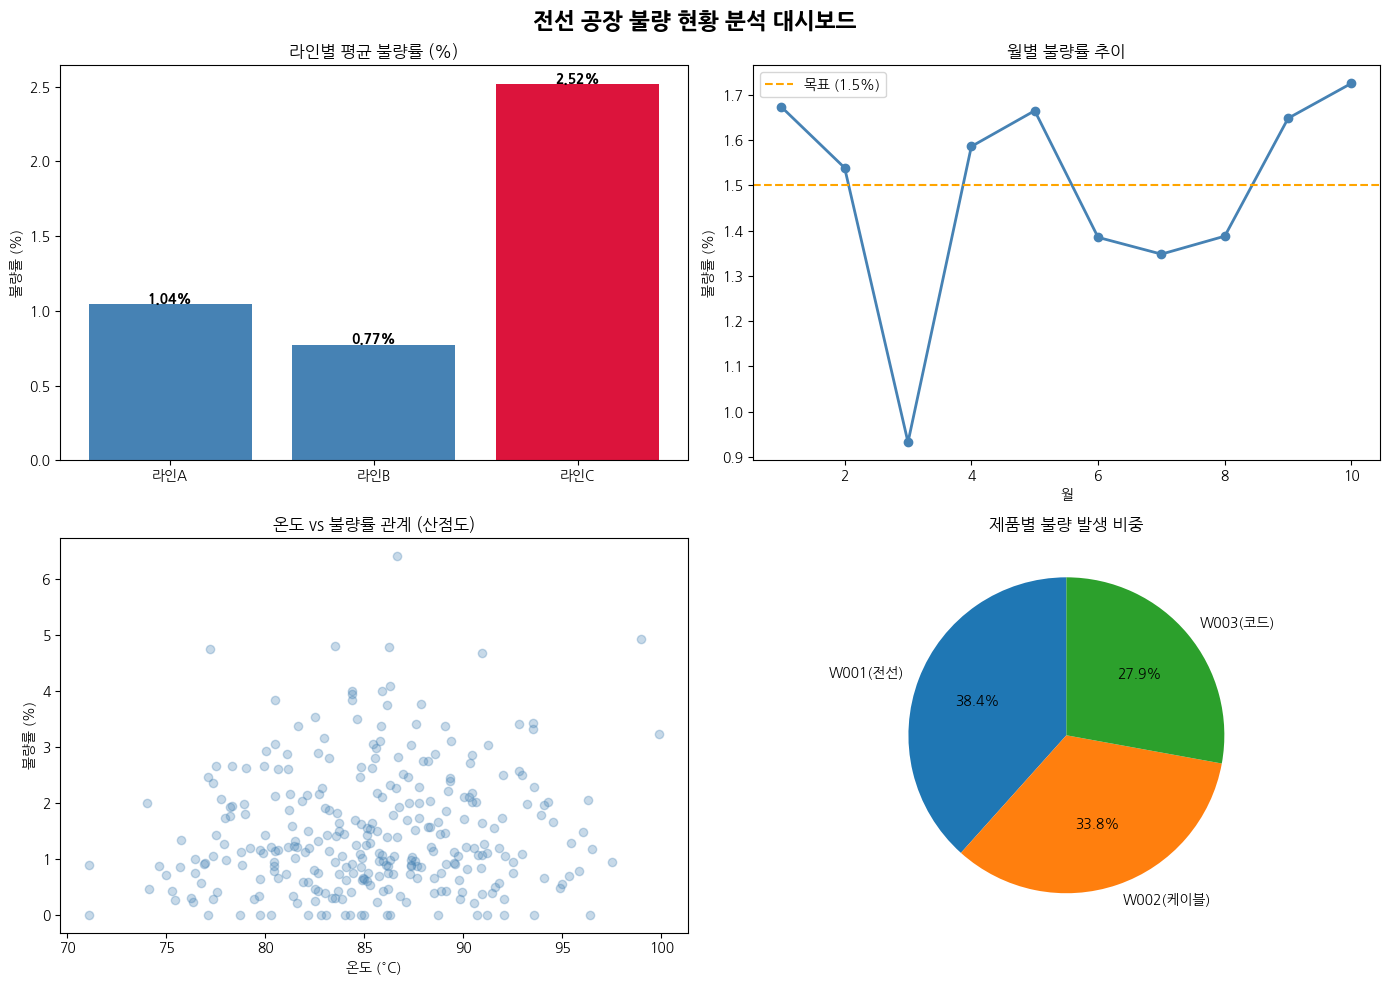


분석 결론
  라인A 평균 불량률: 1.04%
  라인B 평균 불량률: 0.77%
  라인C 평균 불량률: 2.52% ← 문제 라인!

  → 라인C가 라인A 대비 2.4배 높은 불량률
  → 라인C 원인 분석이 최우선 과제입니다.


In [7]:
# ─────────────────────────────────────────────────────────
# 그래프 캔버스(도화지) 설정
# plt.subplots(행, 열): 그래프를 배치할 격자 만들기
#   예: subplots(2, 2)는 2행×2열 = 4개 그래프 공간
# figsize=(가로, 세로): 전체 그림 크기 (인치 단위)
# fig: 전체 도화지 / axes: 각 그래프 칸 (2차원 배열)
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 전체 제목 설정
# fontsize: 글자 크기 / fontweight='bold': 굵게
fig.suptitle('전선 공장 불량 현황 분석 대시보드', fontsize=16, fontweight='bold')

# ─── 그래프 1: 라인별 평균 불량률 막대그래프 ──────────────────
# axes[0, 0]: 1행 1열 (왼쪽 위)
라인 = ['라인A', '라인B', '라인C']
평균값 = [data[data['라인'] == l]['불량률(%)'].mean() for l in 라인]
#   위 코드는 리스트 컴프리헨션: "각 라인별 평균을 계산하여 목록으로 만들기"

# 라인C만 빨간색으로 강조 (색으로 문제 라인을 눈에 띄게)
colors = ['steelblue', 'steelblue', 'crimson']
axes[0, 0].bar(라인, 평균값, color=colors)
axes[0, 0].set_title('라인별 평균 불량률 (%)', fontsize=12)
axes[0, 0].set_ylabel('불량률 (%)')

# 막대 위에 수치 표시
for i, v in enumerate(평균값):  # enumerate: 인덱스(번호)와 값을 동시에 꺼냄
    axes[0, 0].text(i, v + 0.01, f'{v:.2f}%',  # f'{값:.2f}': 소수점 2자리 형식
                    ha='center', fontweight='bold')  # ha: horizontal alignment

# ─── 그래프 2: 월별 불량률 추이 꺾은선그래프 ──────────────────
# axes[0, 1]: 1행 2열 (오른쪽 위)
월별 = data.groupby('월')['불량률(%)'].mean()
axes[0, 1].plot(
    월별.index,     # x축: 월
    월별.values,    # y축: 불량률
    marker='o',    # 각 데이터 점에 동그라미(o) 표시
    linewidth=2,   # 선 굵기
    color='steelblue'
)
# 목표선 추가: 수평 점선으로 목표값 표시
axes[0, 1].axhline(y=1.5, color='orange', linestyle='--', label='목표 (1.5%)')
axes[0, 1].set_title('월별 불량률 추이', fontsize=12)
axes[0, 1].set_xlabel('월')
axes[0, 1].set_ylabel('불량률 (%)')
axes[0, 1].legend()  # 범례(legend) 표시

# ─── 그래프 3: 온도 vs 불량률 산점도 ─────────────────────────
# axes[1, 0]: 2행 1열 (왼쪽 아래)
# 산점도: 두 변수의 관계를 점으로 나타냄 (상관관계 파악에 유용)
axes[1, 0].scatter(
    data['온도(°C)'],  # x축
    data['불량률(%)'],  # y축
    alpha=0.3,         # 투명도 (0=완전투명, 1=불투명) - 겹치는 점 구분
    color='steelblue'
)
axes[1, 0].set_title('온도 vs 불량률 관계 (산점도)', fontsize=12)
axes[1, 0].set_xlabel('온도 (°C)')
axes[1, 0].set_ylabel('불량률 (%)')

# ─── 그래프 4: 제품별 불량 비중 원형그래프 ───────────────────
# axes[1, 1]: 2행 2열 (오른쪽 아래)
제품별 = data.groupby('제품코드')['불량수'].sum()
axes[1, 1].pie(
    제품별,             # 데이터
    labels=제품별.index, # 각 조각의 레이블
    autopct='%1.1f%%',  # 각 조각에 퍼센트 자동 표시
    startangle=90       # 시작 각도
)
axes[1, 1].set_title('제품별 불량 발생 비중', fontsize=12)

# ─────────────────────────────────────────────────────────
# 전체 레이아웃 정리 및 저장
# tight_layout(): 그래프들이 겹치지 않도록 자동 여백 조정
# ─────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('불량분석_대시보드.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 50)
print("분석 결론")
print("=" * 50)
print(f"  라인A 평균 불량률: {평균값[0]:.2f}%")
print(f"  라인B 평균 불량률: {평균값[1]:.2f}%")
print(f"  라인C 평균 불량률: {평균값[2]:.2f}% ← 문제 라인!")
print(f"\n  → 라인C가 라인A 대비 {평균값[2]/평균값[0]:.1f}배 높은 불량률")
print("  → 라인C 원인 분석이 최우선 과제입니다.")

## 정리 및 핵심 포인트

### 배운 것
1. **pandas**: 엑셀처럼 데이터를 표로 다루는 도구
2. **matplotlib**: 그래프를 그리는 도구
3. **groupby()**: 카테고리별로 묶어서 통계 계산 (엑셀 피벗테이블과 동일)
4. **시각화의 힘**: 숫자보다 그래프가 패턴을 훨씬 빠르게 보여줌

### 현장 적용 방법
- 이 코드의 `data` 부분에 **실제 MES/ERP 데이터**를 연결하면 바로 활용 가능
- `np.random.seed(42)` 부터 `data['불량률(%)'] = ...` 까지를 실제 데이터 불러오기로 교체

### 다음 단계
**예제 2**에서는 이 데이터를 활용하여 **AI가 불량을 예측**하는 모델을 만듭니다! 🤖

---
*송현그룹 mAX Academy 3기 | 예제 1/6*